In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import zipfile
from pathlib import Path
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.applications import ResNet152
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import roc_auc_score, f1_score

In [ ]:
# Create the ImageDataGenerator for data preprocessing
image_size = (256, 256)
batch_size = 4
epochs = 1000
train_directory = "BIRDS\\TRAIN"
validation_directory = "BIRDS\\TEST"

datagen = ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    rescale = 1./255)

train_generator = datagen.flow_from_directory(
    train_directory,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)
valid_generator = datagen.flow_from_directory(
    validation_directory,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 45084 images belonging to 62 classes.
Found 6853 images belonging to 62 classes.


In [ ]:
# Define the input shape
input_shape = (256, 256, 3)

# Create the ResNet50 base model with pre-trained weights
base_model = ResNet152(
    include_top=False,
        input_tensor=tf.keras.Input(shape=input_shape),
          weights='imagenet'
)

# Define the Sequential model
model_resnet = Sequential([
    tf.keras.layers.InputLayer(input_shape=input_shape),  # Specify the input shape
    base_model,

    GlobalAveragePooling2D(),

    Dense(train_generator.num_classes, activation='softmax')
])

model_resnet.summary()

# Compile the model
model_resnet.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss=CategoricalCrossentropy(),
    metrics=['accuracy']
)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet152 (Functional)      (None, 8, 8, 2048)        58370944  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 62)                127038    
                                                                 
Total params: 58,497,982
Trainable params: 58,346,558
Non-trainable params: 151,424
_________________________________________________________________


In [ ]:

import os
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define the checkpoint directory and file
checkpoint_dir = "D:\\loonibha\\62birds"
checkpoint_filepath = "D:\\loonibha\\62birds\\model_checkpoints_10.weights.h5"
log_file_path = 'D:\\loonibha\\62birds\\training_log_10.csv'

# Ensure the directory exists
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"Checkpoint filepath: {checkpoint_filepath}")
print(f"Checkpoint filepath: {log_file_path}")
# List files in the checkpoint directory
files_in_directory = os.listdir(checkpoint_dir)
print(f"Files in checkpoint directory: {files_in_directory}")
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
# Define the ModelCheckpoint callback
checkpoint_cb = ModelCheckpoint(filepath=checkpoint_filepath,
                                save_weights_only=True,
                                save_best_only=False,
                                verbose=1)

# Define CSV logger callback
csv_logger = CSVLogger(log_file_path, append=True)


# # Check if checkpoint exists and load weights
initial_epoch = 0
if os.path.exists(checkpoint_filepath):
    print("Checkpoint file found.")
    try:
        model_resnet.load_weights(checkpoint_filepath)
        print("Checkpoint loaded. Resuming training...")
        if os.path.exists(log_file_path):
            print("Log file found.")
            # Read the log file to determine the last completed epoch
            with open(log_file_path, 'r') as f:
                lines = f.readlines()
                if len(lines) > 1:  # If log file is not empty
                    for line in reversed(lines):
                        if line.strip():  # Skip empty lines
                            initial_epoch = int(line.split(',')[0])  # Get the last epoch number
                            print(f"Resuming from epoch {initial_epoch + 1}")
                            break
        else:
            print("No log file found. Starting from scratch.")
    except Exception as e:
        print(f"Error loading checkpoint: {e}")
        print("Starting fresh training...")
else:
    print(f"No checkpoint found at {checkpoint_filepath}. Starting fresh training...")

# Train the model with checkpoint callback
resnet_history = model_resnet.fit(
    train_generator,
    epochs=epochs,
    validation_data=valid_generator,
    initial_epoch=initial_epoch,
    callbacks=[early_stopping, checkpoint_cb,csv_logger]
)


Checkpoint filepath: D:\loonibha\62birds\model_checkpoints_10.weights.h5
Checkpoint filepath: D:\loonibha\62birds\training_log_10.csv
Files in checkpoint directory: ['model_checkpoints_10.weights.h5', 'model_checkpoints_7.weights.h5', 'model_checkpoints_8.weights.h5', 'model_checkpoints_9.weights.h5', 'training_log_10.csv', 'training_log_7.csv', 'training_log_8.csv', 'training_log_9.csv']
Checkpoint file found.
Checkpoint loaded. Resuming training...
Log file found.
Resuming from epoch 7


c:\Users\User\.conda\envs\envcuda\lib\site-packages\keras\preprocessing\image.py:1863: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(
c:\Users\User\.conda\envs\envcuda\lib\site-packages\keras\preprocessing\image.py:1873: UserWarning: This ImageDataGenerator specifies `featurewise_std_normalization`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


Epoch 7/1000
11271/11271 [==============================] - ETA: 0s - loss: 0.2041 - accuracy: 0.9348
Epoch 7: saving model to D:\loonibha\62birds\model_checkpoints_10.weights.h5
11271/11271 [==============================] - 2686s 236ms/step - loss: 0.2041 - accuracy: 0.9348 - val_loss: 0.8076 - val_accuracy: 0.8585
Epoch 8/1000
11271/11271 [==============================] - ETA: 0s - loss: 0.1786 - accuracy: 0.9420
Epoch 8: saving model to D:\loonibha\62birds\model_checkpoints_10.weights.h5
11271/11271 [==============================] - 2099s 186ms/step - loss: 0.1786 - accuracy: 0.9420 - val_loss: 0.8909 - val_accuracy: 0.8544
Epoch 9/1000
11271/11271 [==============================] - ETA: 0s - loss: 0.1635 - accuracy: 0.9471
Epoch 9: saving model to D:\loonibha\62birds\model_checkpoints_10.weights.h5
11271/11271 [==============================] - 2099s 186ms/step - loss: 0.1635 - accuracy: 0.9471 - val_loss: 0.9278 - val_accuracy: 0.8697
Epoch 10/1000
11271/11271 [================

In [ ]:
keras_file = 'resnet50_10.h5'
model_resnet.save(keras_file)

In [ ]:
valid_generator.reset()
predicted_labels = []
true_labels = []
import keras
model1 = keras.models.load_model('resnet50_8.h5')

In [ ]:
true_labels.extend(
    [key for idx in range(len(labels)) for key, value in valid_generator.class_indices.items() if value == np.argmax(labels[idx])]
)
true_labels = [label[0] for label in true_labels]
print("True Labels:", true_labels)


True Labels: ['D', 'D', 'B', 'H', 'D', 'D', 'B', 'H']


In [ ]:
# Fetch a batch of images and labels
images, labels = valid_generator.next()

# Print the shape of the labels array
print("Labels shape:", labels.shape)

# Print the first few labels to understand their structure
print("First few labels:", labels[:5])
import numpy as np

true_labels = []
predicted_labels = []

for i in range(valid_generator.samples // valid_generator.batch_size + 1):
    images, labels = valid_generator.next()

    # Convert one-hot encoded labels to class indices
    label_indices = np.argmax(labels, axis=1)

    # Convert model predictions to class indices
    predictions = model1.predict(images)
    predicted_indices = np.argmax(predictions, axis=1)

    # Map class indices to class names
    class_names = list(valid_generator.class_indices.keys())

    batch_true_labels = [class_names[idx] for idx in label_indices]
    batch_predicted_labels = [class_names[idx] for idx in predicted_indices]

    true_labels.extend(batch_true_labels)
    predicted_labels.extend(batch_predicted_labels)

print("True Labels:", true_labels)
print("Predicted Labels:", predicted_labels)


Labels shape: (4, 62)
First few labels: [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
1/1 [==============================] - 0s 32ms/step
True Labels: ['Garganey', 'Cattle_Egret', 'Eurasian_Crag_Martin', 'Jungle_Myna', 'Gray_Throated_Martin', 'Bronze_Winged_Jacana', 'Black

In [ ]:

for i in range(valid_generator.samples // valid_generator.batch_size + 1):
    images, labels = valid_generator.next()
    predictions = model1.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)
    # predicted_labels.extend([key for key, value in valid_generator.class_indices.items() if value == class_idx][0] for class_idx in predicted_classes)
    # true_labels.extend([key for key, value in valid_generator.class_indices.items() if value == np.argmax(labels[idx]) for idx in range(len(labels))])
    predicted_labels.extend(
    [key for class_idx in predicted_classes for key, value in valid_generator.class_indices.items() if value == class_idx]
    )

# Map true labels to their corresponding classes
    true_labels.extend(
        [key for idx in range(len(labels)) for key, value in valid_generator.class_indices.items() if value == np.argmax(labels[idx])]
    )



1/1 [==============================] - 0s 433ms/step


In [ ]:
true_labels = [label[0] for label in true_labels]
print("True Labels:", true_labels)


In [ ]:
# Print out the true labels to see what's inside
print("True Labels:", true_labels)
class_indices = valid_generator.class_indices
print(class_indices)
# # Checking if all true_labels exist in the class_indices
# for label in true_labels:
#     prin
#     if label not in valid_generator.class_indices:
#         print(f"Warning: Label '{label}' not found in class indices.")


True Labels: ['I', 'R', 'E', 'B', 'C', 'C', 'W', 'I', 'B', 'P', 'C', 'G', 'G', 'L', 'P', 'N', 'J', 'L', 'C', 'B', 'G', 'C', 'C', 'C', 'F', 'H', 'H', 'R', 'B', 'C', 'N', 'H', 'C', 'G', 'B', 'E', 'B', 'C', 'C', 'F', 'B', 'G', 'K', 'I', 'S', 'J', 'B', 'E', 'L', 'H', 'C', 'P', 'G', 'N', 'F', 'B', 'B', 'B', 'J', 'C', 'A', 'A', 'N', 'K', 'M', 'M', 'L', 'H', 'B', 'E', 'H', 'P', 'I', 'B', 'L', 'I', 'S', 'B', 'H', 'P', 'R', 'G', 'C', 'C', 'D', 'F', 'M', 'L', 'C', 'B', 'W', 'G', 'P', 'C', 'L', 'C', 'B', 'E', 'H', 'E', 'R', 'R', 'H', 'L', 'R', 'G', 'S', 'G', 'B', 'E', 'K', 'N', 'B', 'B', 'L', 'F', 'R', 'R', 'P', 'M', 'C', 'R', 'J', 'B', 'R', 'E', 'P', 'C', 'L', 'E', 'R', 'E', 'B', 'R', 'F', 'J', 'H', 'S', 'N', 'H', 'J', 'L', 'H', 'B', 'B', 'L', 'P', 'C', 'C', 'B', 'B', 'H', 'I', 'R', 'C', 'R', 'C', 'H', 'J', 'N', 'I', 'R', 'P', 'N', 'G', 'G', 'G', 'N', 'L', 'R', 'C', 'L', 'S', 'H', 'N', 'R', 'R', 'E', 'H', 'P', 'L', 'E', 'G', 'A', 'N', 'R', 'B', 'C', 'E', 'N', 'G', 'C', 'E', 'B', 'C', 'L', 'G', '

In [ ]:
true_label = [valid_generator.class_indices[label] for label in true_labels]
predicted_label = [valid_generator.class_indices[label] for label in predicted_labels]

In [ ]:
print("Predicted Labels:", predicted_label)
print("True Labels:", true_label)

NameError: name 'predicted_label' is not defined

In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

def calculate_auc_scores(true_labels, predicted_probabilities, num_classes):
    auc_scores = []

    for class_index in range(num_classes):
        binary_true_labels = np.where(true_labels == class_index, 1, 0)
        predicted_scores = predicted_probabilities[:, class_index]

        auc = roc_auc_score(binary_true_labels, predicted_scores)
        auc_scores.append(auc)

    average_auc_score = np.mean(auc_scores)

    return auc_scores, average_auc_score

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score

# Example true labels and predicted labels
true_labels = np.array(true_label)  # Replace with your true labels
predicted_labels = np.array(predicted_label)  # Replace with your predicted labels

# Calculate the AUC score for each class
auc_scores = []
for class_index in range(40):
    # Create binary labels for the current class
    binary_true_labels = np.where(true_labels == class_index, 1, 0)
    binary_predicted_labels = np.where(predicted_labels == class_index, 1, 0)

    # Check if only one instance of the class is present
    if np.sum(binary_true_labels) == 1 or np.sum(binary_predicted_labels) == 1:
        auc = np.nan  # Set AUC score as NaN
    else:
        # Calculate the AUC score for the current class
        auc = roc_auc_score(binary_true_labels, binary_predicted_labels)
    auc_scores.append(auc)

# Calculate the average AUC score
average_auc_score = np.nanmean(auc_scores)

print("AUC Scores for each class:")

print(auc_scores)
print("Average AUC Score:", average_auc_score)

AUC Scores for each class:
[0.9538976129828522, 0.971344390599049, 0.9168616148261282, 0.9472771492016496, 0.9281282316442606, 0.898175566742342, 0.9508823297707519, 0.8799707401993625, 0.9608729779537234, 0.9725274725274725, 0.9919121003465324, 0.9814041955975772, 0.9807479568965708, 1.0, 0.9459115083468754, 0.975784853444428, 0.912144634178278, 0.9817061451122064, 0.9807300928670224, 0.865455289581549, 0.9215241280458674, 0.9158740091781394, 0.8283774857460714, 0.9155887953586873, 0.8135556704584627, 0.9666862416476415, 0.9479355502249242, 0.9841530079917123, 0.9216587876101837, 0.9203291968286798, 0.850892017238739, 0.9309254575212023, 0.8703764407317331, 0.926789297621495, 0.9642454816562618, 0.9495142538620799, 0.9541753035238378, 0.9179776129908416, 0.9801139264367454, 0.9082353177657045]
Average AUC Score: 0.9346165711314409


In [ ]:
from sklearn.metrics import f1_score
import numpy as np

# Example true labels and predicted labels
true_labels = np.array(true_label)  # Replace with your true labels
predicted_labels = np.array(predicted_label)  # Replace with your predicted labels

# Calculate the F1 score for each class
f1_scores = []
for class_index in range(40):
    # Create binary labels for the current class
    binary_true_labels = np.where(true_labels == class_index, 1, 0)
    binary_predicted_labels = np.where(predicted_labels == class_index, 1, 0)

    # Calculate the F1 score for the current class
    f1 = f1_score(binary_true_labels, binary_predicted_labels)
    f1_scores.append(f1)

# Calculate the average F1 score
average_f1_score = np.mean(f1_scores)

print("F1 Scores for each class:")
print(f1_scores)
print("Average F1 Score:", average_f1_score)

F1 Scores for each class:
[0.8547717842323652, 0.8911917098445596, 0.8285714285714286, 0.8421052631578948, 0.888888888888889, 0.835978835978836, 0.9230769230769231, 0.8436018957345972, 0.9130434782608696, 0.9717514124293786, 0.9513888888888888, 0.9257142857142856, 0.9520295202952029, 1.0, 0.9036144578313253, 0.906474820143885, 0.8821917808219178, 0.963855421686747, 0.9665071770334929, 0.8231511254019293, 0.8148148148148148, 0.7888888888888889, 0.7225806451612903, 0.9019607843137254, 0.6503067484662577, 0.711864406779661, 0.9109947643979057, 0.96875, 0.8452380952380952, 0.7634408602150539, 0.7549668874172185, 0.8837209302325582, 0.7336683417085428, 0.8876190476190476, 0.8758169934640523, 0.8770053475935828, 0.9278350515463918, 0.8231292517006803, 0.9733333333333333, 0.7267605633802816]
Average F1 Score: 0.8652651213566198


6853


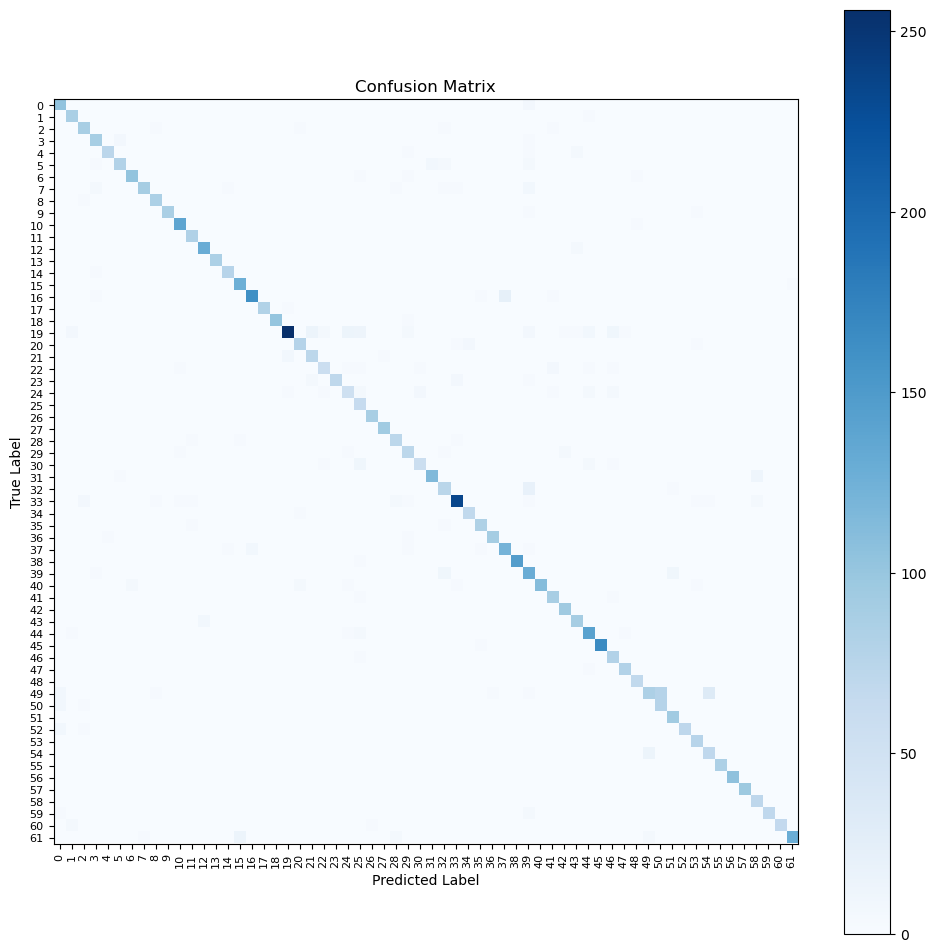

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns

print(len(true_labels))

y_true = np.array(true_label)
y_pred = np.array(predicted_label)

y_true, y_pred
# convert numpy arrays to PyTorch tensors
y_true_t = tf.cast(y_true, dtype='float32')
y_pred_t = tf.cast(y_pred, dtype='float32')


# compute confusion matrix
cm = confusion_matrix(y_true_t, y_pred)

# plot confusion matrix
plt.figure(figsize=(12,12))

plt.imshow(cm, cmap=plt.cm.Blues)
plt.colorbar()

tick_marks = np.arange(len(np.unique(y_true)))
plt.xticks(np.arange(len(np.unique(y_true))), labels=np.unique(y_true), rotation=90)
plt.yticks(np.arange(len(np.unique(y_true))), labels=np.unique(y_true))

plt.tick_params(axis='both', which='major', labelsize=8)

# plt.grid(visible=True, which='both', axis='y', linestyle='--', color='gray', linewidth=0.5)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

In [ ]:
keras_file = 'resnet121.h5'
keras.models.save_model(model1, keras_file)

converter = tf.lite.TFLiteConverter.from_keras_model(model1)
tflite_model = converter.convert()
open('project_revised.tflite','wb').write(tflite_model)

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import numpy as np

# # Load the saved model
model = load_model('resnet50_3.h5')
# model = load_model("C:\\Users\\User\\Downloads\\resnet50_2.h5")
# Test with a sample image
img_path = r'D:\loonibha\Birds_Final\b_final\valid\Black_Bulbul\image_54.jpg'
img = load_img(img_path, target_size=(256, 256))  # Resize as per your model's input size
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
# Normalize the image array (since the training images were normalized)
img_array = img_array / 255.0

# Make a prediction
predictions = model.predict(img_array)
print("Predictions:", predictions)

# # Load the saved model
# model = load_model("C:\\Users\\User\\Downloads\\resnet50_2.h5")

# # Test with a sample image
# img_path = r'D:\loonibha\Birds_Final\b_final\valid\Black_Bulbul\image_54.jpg'
# img = image.load_img(img_path, target_size=(128, 128))
# img_array = image.img_to_array(img)
# img_array = np.expand_dims(img_array, axis=0)
# img_array /= 255.0  # Normalize the image

# # Predict
# predictions = model.predict(img_array)
# print(predictions)


ValueError: Unrecognized keyword arguments: ['batch_shape']

In [ ]:
import tensorflow as tf
import keras

print(tf.__version__)
print(keras.__version__)

2.10.1
2.10.0


In [ ]:
import numpy as np
from keras.models import load_model
from keras.preprocessing import image

# Load the saved model with compile=Falsefrom keras.models import load_model
from custom_objects import CustomLayer  # Replace with your actual custom objects

model = load_model("C:\\Users\\User\\Downloads\\resnet50_2.h5", custom_objects={'CustomLayer': CustomLayer})

# model = load_model("C:\\Users\\User\\Downloads\\resnet50_2.h5", compile=False)

# Test with a sample image
img_path = r'D:\loonibha\Birds_Final\b_final\valid\Black_Bulbul\image_54.jpg'
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0  # Normalize the image

# Predict
predictions = model.predict(img_array)
print(predictions)


ModuleNotFoundError: No module named 'custom_objects'

In [ ]:
resnet_predicted_labels = []
resnet_true_labels = []

valid_generator = datagen.flow_from_directory(
    'b_final\\valid',
    target_size=(128, 128),  # Resize images to match model input
    batch_size=32,
    class_mode='categorical'
)
resnet_predicted_labels = []
resnet_true_labels = []

valid_generator.reset()
for i in range(valid_generator.samples // valid_generator.batch_size + 1):
    images, labels = valid_generator.next()

    # No need to resize images here if already resized by the generator
    # Normalize images if not already normalized
    images = images / 255.0  # Ensure images are normalized

    predictions = model_resnet.predict(images)

    predicted_classes = np.argmax(predictions, axis=1)
    resnet_predicted_labels.extend([key for key, value in valid_generator.class_indices.items() if value == class_idx][0] for class_idx in predicted_classes)
    resnet_true_labels.extend([key for key, value in valid_generator.class_indices.items() if value == np.argmax(labels[idx])] for idx in range(len(labels)))

# Optionally, compute accuracy or other metrics
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(resnet_true_labels, resnet_predicted_labels)
print(f'Validation accuracy: {accuracy}')



Found 8102 images belonging to 62 classes.
1/1 [==============================] - 1s 1s/step
Validation accuracy: 0.008146136756356455


In [ ]:
# resnet_true_labels = [label[0] for label in resnet_true_labels]
# resnet_true_label = [valid_generator.class_indices[label] for label in resnet_true_labels]
# resnet_predicted_label = [valid_generator.class_indices[label] for label in resnet_predicted_labels]
# Convert true labels to indices
resnet_true_label_indices = [valid_generator.class_indices[label] for label in resnet_true_labels if label in valid_generator.class_indices]

# Convert predicted labels to indices
resnet_predicted_label_indices = [valid_generator.class_indices[label] for label in resnet_predicted_labels if label in valid_generator.class_indices]

# Check for missing labels
missing_true_labels = [label for label in resnet_true_labels if label not in valid_generator.class_indices]
missing_predicted_labels = [label for label in resnet_predicted_labels if label not in valid_generator.class_indices]

print("Missing true labels:", missing_true_labels)
print("Missing predicted labels:", missing_predicted_labels)


Missing true labels: ['B', 'L', 'C', 'H', 'J', 'E', 'N', 'N', 'R', 'R', 'J', 'E', 'N', 'H', 'G', 'G', 'C', 'L', 'W', 'B', 'B', 'C', 'B', 'C', 'E', 'H', 'C', 'N', 'A', 'R', 'L', 'E', 'M', 'I', 'G', 'C', 'B', 'N', 'D', 'L', 'L', 'H', 'I', 'N', 'G', 'L', 'E', 'I', 'L', 'A', 'H', 'K', 'R', 'D', 'E', 'N', 'G', 'C', 'E', 'C', 'G', 'C', 'C', 'R', 'N', 'R', 'L', 'B', 'B', 'H', 'N', 'B', 'I', 'R', 'N', 'L', 'M', 'R', 'E', 'W', 'H', 'B', 'R', 'C', 'S', 'B', 'H', 'L', 'D', 'B', 'L', 'M', 'N', 'W', 'A', 'B', 'G', 'L', 'L', 'P', 'N', 'B', 'B', 'E', 'H', 'P', 'L', 'H', 'L', 'P', 'R', 'B', 'L', 'B', 'B', 'L', 'B', 'L', 'D', 'C', 'L', 'C', 'M', 'C', 'K', 'C', 'C', 'H', 'G', 'R', 'L', 'N', 'R', 'N', 'E', 'H', 'E', 'G', 'N', 'P', 'D', 'R', 'E', 'C', 'P', 'H', 'L', 'C', 'N', 'B', 'N', 'B', 'L', 'D', 'N', 'L', 'R', 'L', 'C', 'E', 'G', 'L', 'N', 'P', 'E', 'N', 'L', 'R', 'S', 'R', 'L', 'K', 'L', 'E', 'L', 'L', 'H', 'N', 'G', 'R', 'L', 'N', 'D', 'E', 'L', 'N', 'C', 'L', 'L', 'L', 'L', 'R', 'W', 'I', 'B', 'B'

In [ ]:
import tensorflow as tf

# Print available devices
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.config.list_physical_devices('GPU'))

# Create a simple computation to test GPU
if len(tf.config.list_physical_devices('GPU')) > 0:
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
        b = tf.constant([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
        c = tf.matmul(a, b)
        print(c)
else:
    print("No GPU found.")


Num GPUs Available:  0
[]
No GPU found.


In [ ]:
import os

checkpoint_filepath = "D:\\loonibha\\62birds\\model_checkpoints.weights.h5"

if os.path.exists(checkpoint_filepath):
    print("Checkpoint file successfully saved.")
else:
    print("Checkpoint file not found.")

In [ ]:
initial_epoch = 0

# Check if the checkpoint file exists
if os.path.exists(checkpoint_filepath):
    try:
        model_resnet.load_weights(checkpoint_filepath)
        print("Checkpoint loaded. Resuming training...")
        # Load the last completed epoch if applicable (for informational purposes)
        # TensorFlow does not natively track the last epoch in the checkpoint file
    except Exception as e:
        print(f"Error loading checkpoint: {e}")
        print("Starting fresh training...")
else:
    print(f"No checkpoint found at {checkpoint_filepath}. Starting fresh training...")


In [ ]:
def check_gpu():
    devices = tf.config.list_physical_devices('GPU')
    if len(devices) == 0:
        print("No GPU devices found.")
    else:
        print(f"Found {len(devices)} GPU(s):")
        for device in devices:
            print(f"  - {device.name}")

In [ ]:
check_gpu()

In [ ]:

def configure_gpus():
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:

        try:
            # Restrict TensorFlow to only use the first GPU
            tf.config.set_visible_devices(gpus[1], 'GPU')

            # Set memory growth to prevent TensorFlow from allocating all memory on the GPU at once
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(f"Error configuring GPUs: {e}")

In [ ]:
configure_gpus()

In [ ]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print(f"Visible devices: {gpus}")

Visible devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import tensorflow as tf

def check_tensorflow_gpu():
    physical_devices = tf.config.list_physical_devices('GPU')
    if not physical_devices:
        print("No GPU devices found.")
    else:
        print(f"Found {len(physical_devices)} GPU(s):")
        for device in physical_devices:
            print(f"  - {device.name}")
            details = tf.config.experimental.get_device_details(device)
            print(f"    Memory Limit: {details.get('memory_limit')} bytes")
            print(f"    Compute Capability: {details.get('compute_capability')}")
            print(f"    Device Type: {details.get('device_type')}")

if __name__ == "__main__":
    check_tensorflow_gpu()
